# 📊 KickProphet: Data Analysis

In questo notebook analizziamo il dataset processato `KICKSTARTER_TRAIN.csv` generato dallo script `preprocessing.py`. L'obiettivo è comprendere le distribuzioni delle feature e le loro correlazioni con il target (`successful` vs `failed`).

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configurazione Plot
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. CARICAMENTO
train_path = '../data/processed/KICKSTARTER_TRAIN.csv'
df = pd.read_csv(train_path)
print(f"📊 Dataset caricato: {df.shape}")

📊 Dataset caricato: (150491, 527)


## 🎯 1. Distribuzione del Target
Verifichiamo il bilanciamento delle classi.

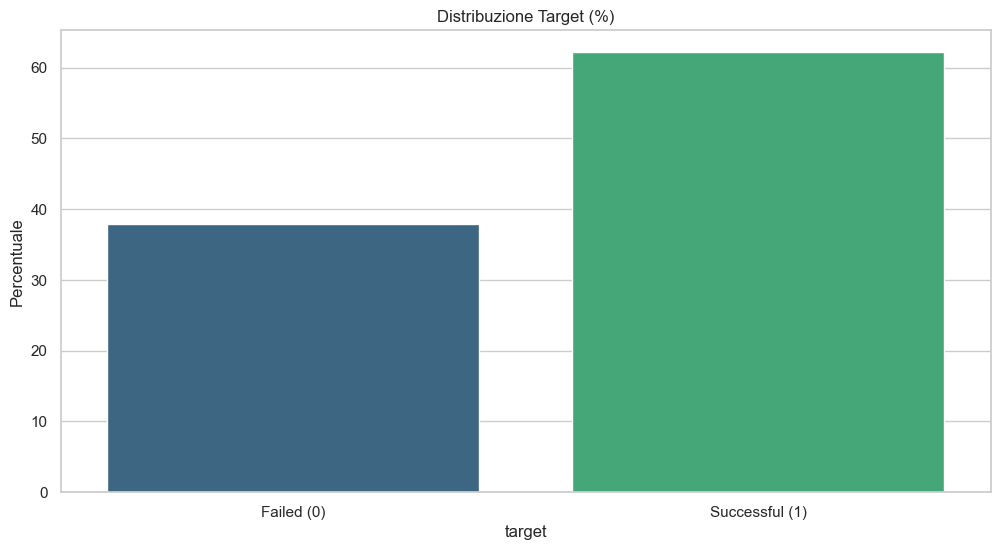

Bilanciamento:
target
1    62.167173
0    37.832827
Name: proportion, dtype: float64


In [16]:
target_counts = df['target'].value_counts(normalize=True) * 100
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, palette="viridis", legend=False)
plt.title("Distribuzione Target (%)")
plt.xticks([0, 1], ['Failed (0)', 'Successful (1)'])
plt.ylabel("Percentuale")
plt.show()

print(f"Bilanciamento:\n{target_counts}")

## 📈 2. Analisi delle Feature Numeriche
Esaminiamo le distribuzioni delle feature principali.

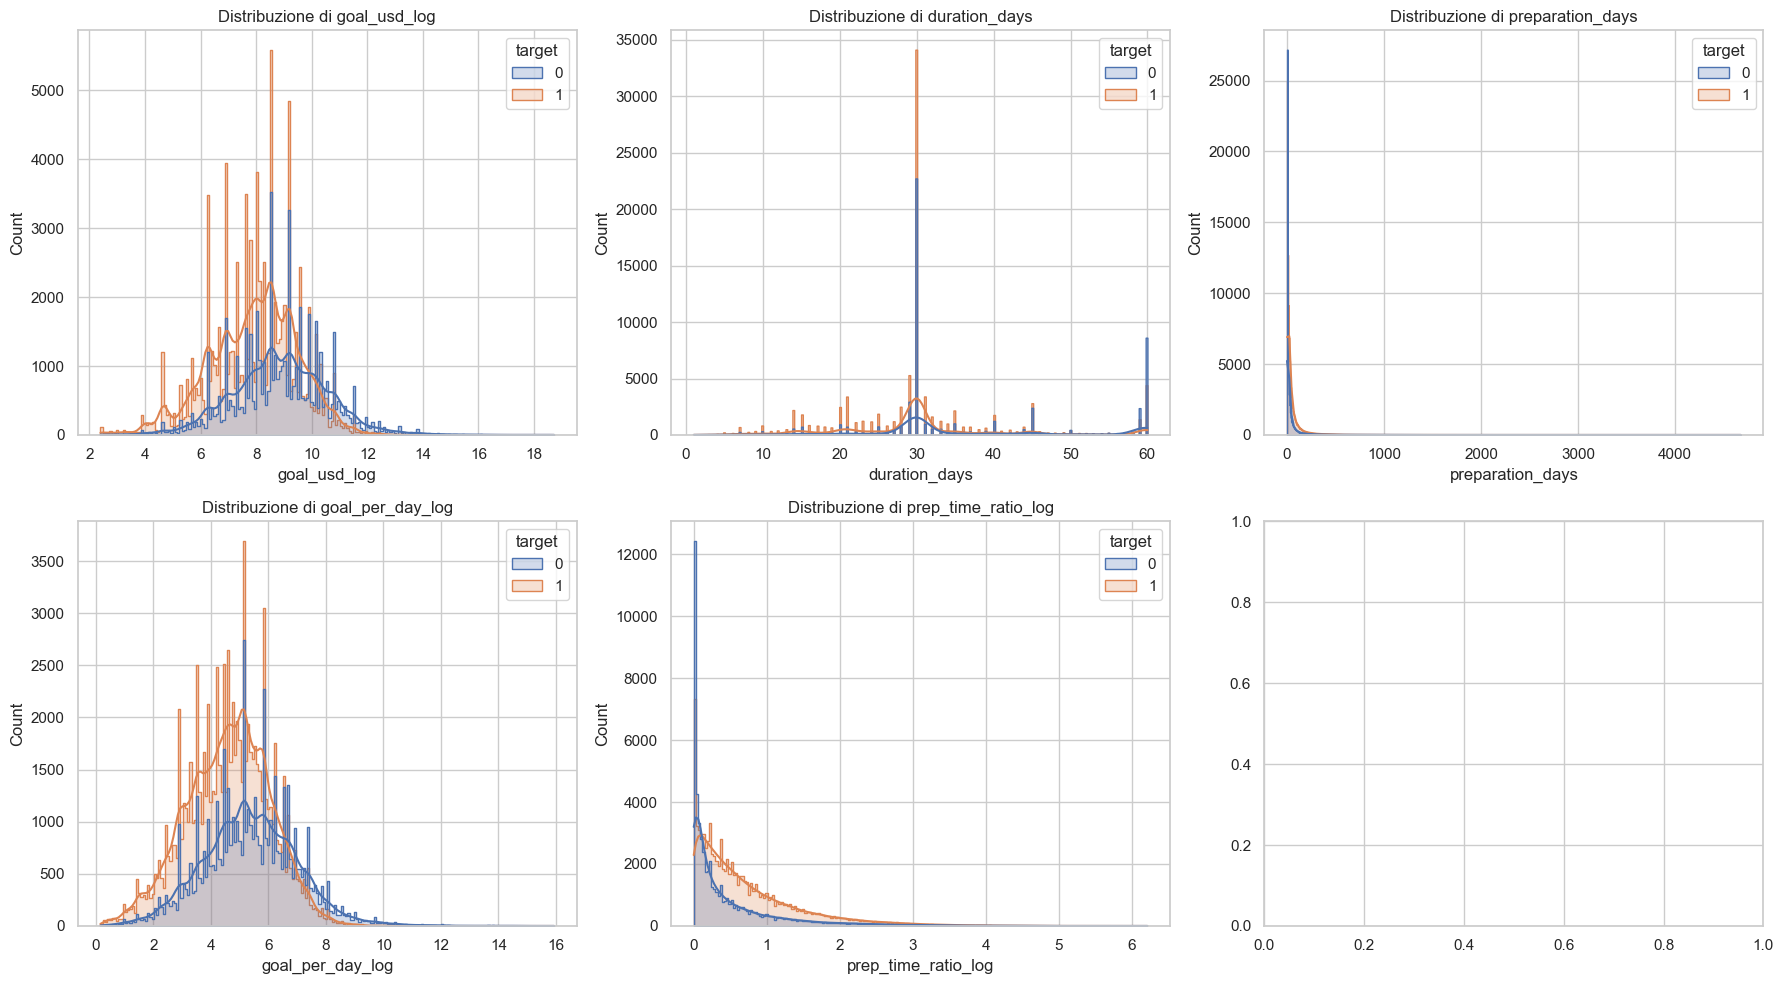

In [17]:
key_cols = ['goal_usd_log', 'duration_days', 'preparation_days', 'goal_per_day_log', 'prep_time_ratio_log']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    sns.histplot(df, x=col, hue="target", kde=True, ax=axes[i], element="step")
    axes[i].set_title(f"Distribuzione di {col}")

plt.tight_layout()
plt.show()

## 🔗 3. Correlazione con il Target
Quali feature influenzano maggiormente il successo?

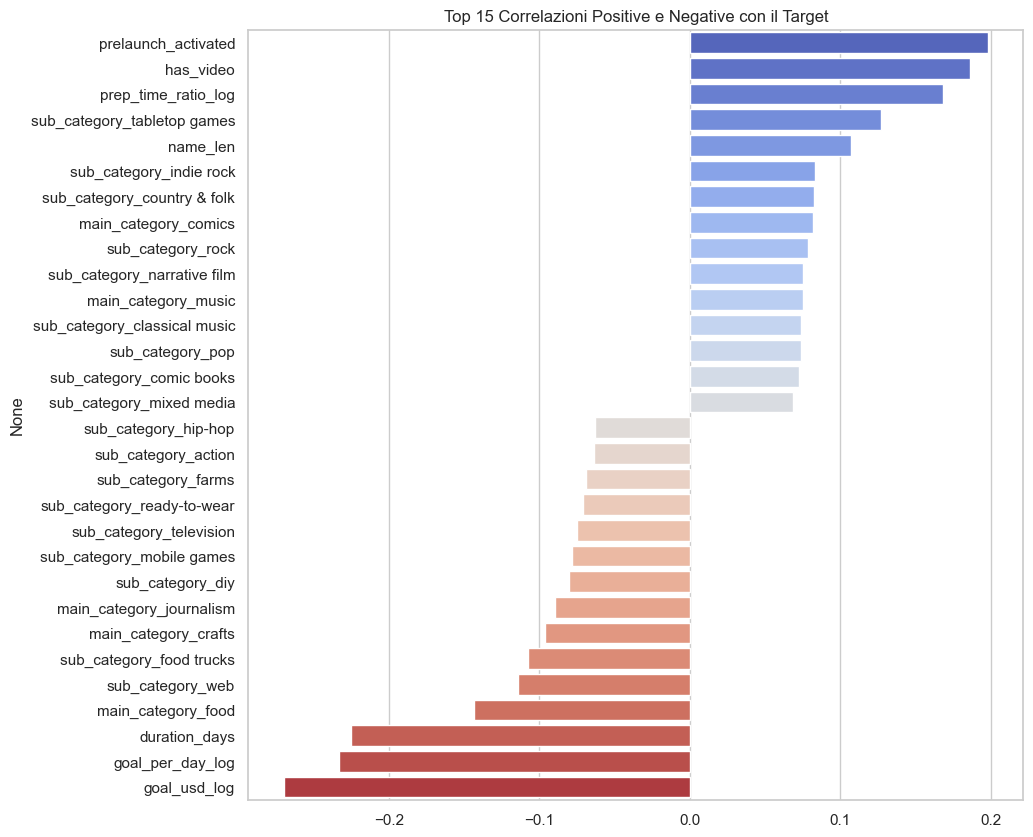

In [18]:
# Escludiamo le colonne TF-IDF per ora per pulizia
base_cols = [c for c in df.columns if not c.startswith('word_')]
correlations = df[base_cols].corr()['target'].sort_values(ascending=False)

# Rimuoviamo il target stesso (sempre 1.0) e prendiamo i top 15 positivi e negativi
correlations = correlations.drop('target', errors='ignore')
top_bottom_corr = pd.concat([correlations.head(15), correlations.tail(15)])

plt.figure(figsize=(10, 10))
sns.barplot(x=top_bottom_corr.values, y=top_bottom_corr.index, hue=top_bottom_corr.index, palette="coolwarm", legend=False)
plt.title("Top 15 Correlazioni Positive e Negative con il Target")
plt.show()

## 🔤 4. Analisi TF-IDF (Parole chiave)
Vediamo quali parole sono associate ai progetti di successo.

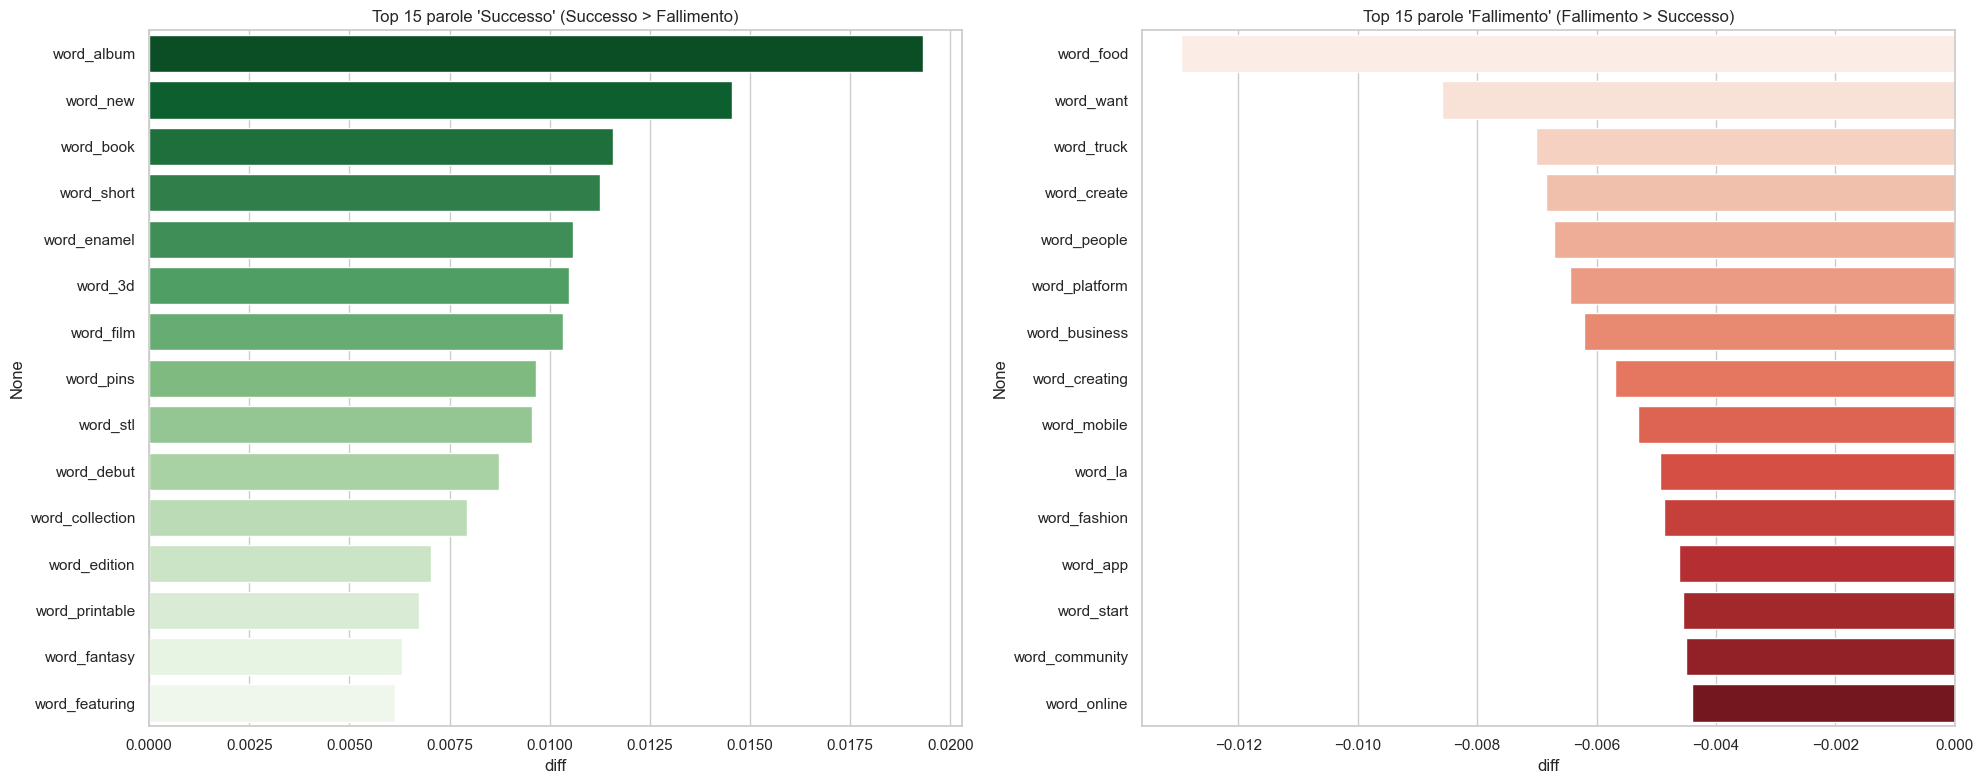

In [19]:
word_cols = [c for c in df.columns if c.startswith('word_')]
if word_cols:
    word_means = df[word_cols + ['target']].groupby('target').mean().T
    word_means['diff'] = word_means[1] - word_means[0]
    
    top_success = word_means.sort_values('diff', ascending=False).head(15)
    top_fail = word_means.sort_values('diff', ascending=True).head(15)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.barplot(x=top_success['diff'], y=top_success.index, ax=ax1, hue=top_success.index, palette="Greens_r", legend=False)
    ax1.set_title("Top 15 parole 'Successo' (Successo > Fallimento)")
    
    sns.barplot(x=top_fail['diff'], y=top_fail.index, ax=ax2, hue=top_fail.index, palette="Reds", legend=False)
    ax2.set_title("Top 15 parole 'Fallimento' (Fallimento > Successo)")
    
    plt.tight_layout()
    plt.show()